# Leilei Sleep Classification Workflow

This notebook provides a complete parameter-driven pipeline for preparing EEG data, testing pre-trained models, training models from scratch, fine-tuning existing models, and running pure inference to securely classify new recordings without overwriting human annotations. It's written by Leilei Hao and updated by Zhuowen Yin.

### **Workflow Sections:**
1. **Prepare Data**: Loading `.mat` data, creating overlapping segments, parsing standard/extended stages, and creating PyTorch DataLoaders. Data loads dynamically based on global settings.
2. **Setup and Test a Pre-Trained Model**: Load existing Stage 1 (`biLSTM`) and Stage 2 (`FCNet`) models, evaluate on the test split, and visualize the confusion matrix.
3. **Train Models from Scratch**: Build raw architecture dynamically tuned to `global_model_output_dim` and train entirely on the loaded dataset.
4. **Fine-Tuning a Loaded Model**: Initialize weights from pre-trained architectures but refine on a custom mapping or expanded label space.
5. **Inference on Unannotated Data**: Run pure classification on new `.mat` recordings using zero padding for unannotated edges, and output purely to `remidx_sleepclass_<name>.txt`.

## 1. Setup and Data Loading

Set the sleep stages we use for the workflow (default REM, Wake, NREM, can add extra ones).

Prepare the train/test datasets for the recordings loop. We load `EEG`, `EMG`, and targets (`M`).

Below: Setup paths and recordings for training and testing:

In [ ]:
import os
import sys
import numpy as np
import scipy.io as so
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import importlib
sys.path.append('Your_Path_to_PySleep_Code\\PySleep')
import sleepy

# Import our custom modules
import models
import data_utils as du

# Reload modules to grab any underlying .py file changes without restarting kernel
importlib.reload(models)
importlib.reload(du)
from models import biLSTM, FCNet, CPU_Unpickler

torch.manual_seed(100)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

## Path definitions and globals

ppath = 'Your_Path_to_Data\\intermedie_REM_EEG'
model_path = './'

# Manually choose which recordings are for training and testing
train_recordings = ['train_recording_name_1', 'train_recording_name_2', 'train_recording_name_3']
test_recordings = ['test_recording_name_1', 'test_recording_name_2', 'test_recording_name_3']

# Set this flag explicitly to run testing accuracy steps. 
# If tests are just placeholders without actual annotations, set this to False.
run_test_evaluation = True

ndown = 4
factor = 2500
segment_length = 51
overlap = 50
window_size = 625
batch_size = 512

Using device: cuda:0


In [ ]:
def prepare_data(recording_list, ext_sleep_stages=None):
    if ext_sleep_stages is None:
        ext_sleep_stages = {}
        
    all_inputs = []
    all_m = []
    
    valid_stages = [1, 2, 3] + list(ext_sleep_stages.keys())
    # Max determines class dimensions needed for PyTorch bounds (handles non-sequential additions)
    num_classes = max(valid_stages) if valid_stages else 3
    
    for recording_name in recording_list:
        print(f'Loading arrays for {recording_name}...')
        try:
            m, _ = du.load_stateidx(ppath, recording_name)
        except Exception as e:
            print(f"Skipping {recording_name}: {e}")
            continue
            
        m = m.astype('i')[:-1] 
        len_m = len(m)

        eeg = so.loadmat(os.path.join(ppath, recording_name, 'EEG.mat'), squeeze_me=True)['EEG']
        eeg = eeg[:(len_m) * factor]
        eeg = sleepy.downsample_vec(eeg, ndown).astype('float16')

        emg = so.loadmat(os.path.join(ppath, recording_name, 'EMG.mat'), squeeze_me=True)['EMG']
        emg = emg[:(len_m) * factor]
        emg = sleepy.downsample_vec(emg, ndown).astype('float16')

        for i in range(len(m)):
            if m[i] not in valid_stages:
                m[i] = 3 # Group unknown or unspecified stages into NREM

        m_upsampled = np.repeat(m, int(factor/ndown))
        x_input = np.vstack((eeg, emg)).T
        inputs = StandardScaler().fit_transform(x_input)
        
        all_inputs.append(inputs)
        all_m.append(m_upsampled)

    if not all_inputs:
        print("No valid recordings to load.")
        return None

    combined_inputs = np.vstack(all_inputs)
    combined_m = np.concatenate(all_m)

    dataset = du.CustomDataset(combined_inputs, combined_m, window_size=window_size, num_classes=num_classes)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    return loader

# Refactored helper: Convert Stage 1 predictions into segmented Stage 2 features
def extract_stage2_features(model, loader):
    if loader is None: return None
    print("Extracting Stage 2 features using biLSTM...")
    model.eval()
    predicted_labels = []
    real_labels = []
    with torch.no_grad():
        for inputs, target in loader:
            inputs, target = inputs.to(device).double(), target.to(device).double()
            output = model(inputs)
            predicted_labels.extend(output.tolist())
            
            target_classes = torch.argmax(target, dim=1) + 1
            real_labels.extend(target_classes.tolist())

    idx = int(overlap/2)
    segments = np.array(du.create_segments(predicted_labels, segment_length, overlap))
    labels_s2 = real_labels[idx:len(real_labels) - idx]

    axis = (0, 2)
    mean_x = np.nanmean(segments, axis=axis, keepdims=True)
    std_x = np.nanstd(segments, axis=axis, keepdims=True)
    std_x[std_x == 0] = 1 # Avoid div by zero
    segments = ((segments - mean_x) / std_x).astype('<f8')

    return du.CustomDatasetFC(segments, labels_s2)

In [8]:
# =============================================================================
# Custom Parameters for Sleep Stages
# Set `use_extended_stages = True` to enable dynamically added stages across the entire notebook
# =============================================================================

use_extended_stages = True 

# Define extra sleep stages if the above flag is True
# Example: global_ext_sleep_stages = {4: 'IS', 5: 'MA'}
global_ext_sleep_stages = {4: 'IS'} 

if use_extended_stages:
    active_ext_stages = global_ext_sleep_stages
else:
    active_ext_stages = {}

# Compute dynamic mappings for the pipeline
global_valid_stages = [1, 2, 3] + list(active_ext_stages.keys())
global_class_names = ['REM', 'Wake', 'NREM'] + list(active_ext_stages.values())
global_model_output_dim = max(global_valid_stages) if global_valid_stages else 3

print(f"--- Preparing Training Data ({global_model_output_dim} stages) ---")
train_loader = prepare_data(train_recordings, ext_sleep_stages=active_ext_stages)

print(f"\n--- Preparing Testing Data ({global_model_output_dim} stages) ---")
test_loader = prepare_data(test_recordings, ext_sleep_stages=active_ext_stages)

--- Preparing Training Data (4 stages) ---
Loading arrays for JK356_052824n1...
remdix
Loading arrays for JK358_052824n1...
remdix
Loading arrays for JK369_060124n1...
remdix
Loading arrays for JK370_060124n1...
remdix

--- Preparing Testing Data (4 stages) ---
Loading arrays for JK371_053024n1...
remdix


## 2. Testing a Pre-Trained Model
This is the default behavior, loading existing Stage1 / Stage2 metrics, running predictions, mapping confusion vectors, and plotting outputs.


Extracting Stage 2 features using biLSTM...
Pre-Trained Stage 2 Testing Accuracy on 4 stages: 87.43%


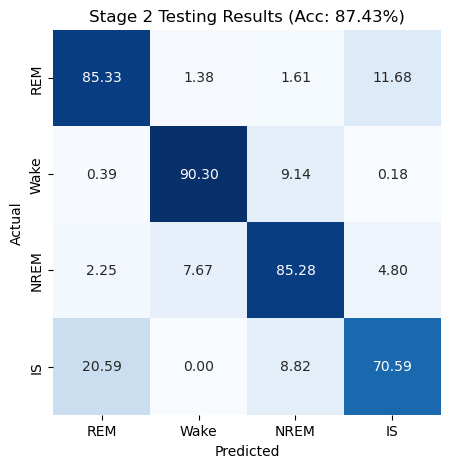

In [ ]:
# Load pre-trained models
stage1_path = os.path.join(model_path, 'Stage1_tuned_4stages.pkl')  
# Change Stage2_tuned.pkl back to Stage2_pretrained.pkl if you want to test the original model
stage2_path = os.path.join(model_path, 'Stage2_tuned_4stages.pkl') 

bilstm_model = du.safe_load_model(stage1_path, device)
fc_model = du.safe_load_model(stage2_path, device)

bilstm_model.eval()
fc_model.eval()

# Use the extracted test loader and pipe it straight through Stage 1 & Stage 2 structures
test_dataset_fc = extract_stage2_features(bilstm_model, test_loader)

if not run_test_evaluation:
    print("\nTest labels are not found (or test evaluation is globally skipped)!")
else:
    pretrained_test_loader_fc = DataLoader(test_dataset_fc, batch_size=batch_size, shuffle=False)

    final_test_real_labels, final_test_predicted_labels = [], []
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for iter, (inputs, target) in enumerate(pretrained_test_loader_fc):
            inputs, target = inputs.to(device).double(), target.to(device).double()
            
            val_output = fc_model(inputs)
            val_output_classes = torch.argmax(val_output, dim=1) + 1
            
            # Stage 2 CustomDatasetFC directly yields class integer targets, not one-hot
            target_classes = target
            
            final_test_predicted_labels.extend(val_output_classes.tolist())
            final_test_real_labels.extend(target_classes.tolist())
            
            test_correct += (val_output_classes == target_classes).sum().item()
            test_total += target_classes.size(0)

    test_acc = 100.0 * test_correct / max(test_total, 1)
    print(f"Pre-Trained Stage 2 Testing Accuracy on {global_model_output_dim} stages: {test_acc:.2f}%")

    # Plot results
    # Dynamically mapping the confusion matrix for the designated stages
    cf_matrix = confusion_matrix(final_test_real_labels, final_test_predicted_labels, labels=global_valid_stages)
    cf_matrix_normalized = cf_matrix / (cf_matrix.sum(axis=1, keepdims=True) + 1e-10) * 100

    plt.figure(figsize=(5, 5), dpi=100)
    sns.heatmap(cf_matrix_normalized, annot=True, fmt='.2f', cmap='Blues', cbar=False, 
                xticklabels=global_class_names, yticklabels=global_class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Stage 2 Testing Results (Acc: {test_acc:.2f}%)')
    plt.show()

## 3. Training a Model From Scratch

To train an entirely new model, we will define it from scratch using architectures from models.py.


In [ ]:
# =============================================================================
# Stage 1: biLSTM Training
# =============================================================================
new_bilstm = biLSTM(input_size=2, window_len=window_size, device=device).double().to(device)

if global_model_output_dim != 3:
    # Modify the output projection dynamically if stages are added
    new_bilstm.fc[6] = nn.Linear(64, global_model_output_dim).double().to(device)

criterion_s1 = nn.CrossEntropyLoss()
optimizer_s1 = torch.optim.Adam(new_bilstm.parameters(), lr=0.001)

num_epochs_s1 = 20

print(f"--- Starting Stage 1 (biLSTM) Training ({global_model_output_dim} stages) ---")
for epoch in range(num_epochs_s1):
    new_bilstm.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device).double(), targets.to(device).double()
        
        optimizer_s1.zero_grad()
        outputs = new_bilstm(inputs)
        
        target_classes = torch.argmax(targets, dim=1)
        loss = criterion_s1(outputs, target_classes) 
        loss.backward()
        optimizer_s1.step()
        
        running_loss += loss.item()
        
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == target_classes).sum().item()
        total += targets.size(0)
        
    acc = 100.0 * correct / max(total, 1)
    
    # Test Evaluation
    if run_test_evaluation:
        new_bilstm.eval()
        test_correct, test_total = 0, 0
        with torch.no_grad():
            for test_in, test_tgt in test_loader:
                test_in, test_tgt = test_in.to(device).double(), test_tgt.to(device).double()
                test_out = new_bilstm(test_in)
                test_correct += (torch.argmax(test_out, dim=1) == torch.argmax(test_tgt, dim=1)).sum().item()
                test_total += test_tgt.size(0)
                
        test_acc = 100.0 * test_correct / max(test_total, 1)
        
        print(f'S1 Epoch [{epoch+1}/{num_epochs_s1}] | Train Loss: {running_loss/len(train_loader):.4f} '
              f'| Train Acc: {acc:.2f}% | Test Acc: {test_acc:.2f}%')
    else:
        print(f'S1 Epoch [{epoch+1}/{num_epochs_s1}] | Train Loss: {running_loss/len(train_loader):.4f} '
              f'| Train Acc: {acc:.2f}% | Test labels are not found/skipped!')


# =============================================================================
# Data Preparation for Stage 2
# =============================================================================
print("\n--- Preparing Data for Stage 2 ---")
# Use the helper function to build the overlapping segments based on trained S1 outputs
train_dataset_fc = extract_stage2_features(new_bilstm, train_loader)
train_loader_fc_scratch = DataLoader(train_dataset_fc, batch_size=batch_size, shuffle=True)

test_dataset_fc = extract_stage2_features(new_bilstm, test_loader)
test_loader_fc_scratch = DataLoader(test_dataset_fc, batch_size=batch_size, shuffle=False) if test_dataset_fc else None

# =============================================================================
# Stage 2: FCNet Training
# =============================================================================
new_fcnet = FCNet().double().to(device)

if global_model_output_dim != 3:
    # Modify dimensions dynamically depending on final outputs from Stage 1 segments
    new_fcnet.fc[1] = nn.Linear(segment_length * global_model_output_dim, 64).double().to(device)
    new_fcnet.fc[11] = nn.Linear(32, global_model_output_dim).double().to(device)

criterion_s2 = nn.CrossEntropyLoss()
optimizer_s2 = torch.optim.Adam(new_fcnet.parameters(), lr=0.001)

num_epochs_s2 = 50

print(f"\n--- Starting Stage 2 (FCNet) Training ({global_model_output_dim} stages) ---")
for epoch in range(num_epochs_s2):
    new_fcnet.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, (inputs, targets) in enumerate(train_loader_fc_scratch):
        inputs = inputs.to(device).double()
        targets = targets.to(device).long() - 1  # 0-indexed for CrossEntropyLoss
        
        optimizer_s2.zero_grad()
        outputs = new_fcnet(inputs)
        
        loss = criterion_s2(outputs, targets)
        loss.backward()
        optimizer_s2.step()
        
        running_loss += loss.item()
        
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)
        
    acc = 100.0 * correct / max(total, 1)
    
    # Test Evaluation
    if run_test_evaluation:
        new_fcnet.eval()
        test_correct, test_total = 0, 0
        with torch.no_grad():
            for test_in, test_tgt in test_loader_fc_scratch:
                test_in = test_in.to(device).double()
                test_tgt = test_tgt.to(device).long() - 1
                test_out = new_fcnet(test_in)
                test_correct += (torch.argmax(test_out, dim=1) == test_tgt).sum().item()
                test_total += test_tgt.size(0)
                
        test_acc = 100.0 * test_correct / max(test_total, 1)
        
        print(f'S2 Epoch [{epoch+1}/{num_epochs_s2}] | Train Loss: {running_loss/len(train_loader_fc_scratch):.4f} '
              f'| Train Acc: {acc:.2f}% | Test Acc: {test_acc:.2f}%')
    else:
        print(f'S2 Epoch [{epoch+1}/{num_epochs_s2}] | Train Loss: {running_loss/len(train_loader_fc_scratch):.4f} '
              f'| Train Acc: {acc:.2f}% | Test labels are not found/skipped!')

# Save the newly tuned extended models
torch.save(new_bilstm, f'Stage1_new_{global_model_output_dim}stages.pkl')
torch.save(new_fcnet, f'Stage2_new_{global_model_output_dim}stages.pkl')
print(f"\n--- Saved new models for {global_model_output_dim} stages ---")

--- Starting Stage 1 (biLSTM) Training (4 stages) ---
S1 Epoch [1/20] | Train Loss: 0.9444 | Train Acc: 51.46% | Test Acc: 50.33%
S1 Epoch [2/20] | Train Loss: 0.8869 | Train Acc: 54.12% | Test Acc: 52.57%
S1 Epoch [3/20] | Train Loss: 0.7349 | Train Acc: 68.38% | Test Acc: 63.58%
S1 Epoch [4/20] | Train Loss: 0.8777 | Train Acc: 54.11% | Test Acc: 51.12%
S1 Epoch [5/20] | Train Loss: 0.8972 | Train Acc: 52.08% | Test Acc: 52.91%
S1 Epoch [6/20] | Train Loss: 0.6838 | Train Acc: 70.30% | Test Acc: 83.09%
S1 Epoch [7/20] | Train Loss: 0.3574 | Train Acc: 87.56% | Test Acc: 87.96%
S1 Epoch [8/20] | Train Loss: 0.2736 | Train Acc: 90.41% | Test Acc: 89.87%
S1 Epoch [9/20] | Train Loss: 0.2564 | Train Acc: 90.86% | Test Acc: 88.88%
S1 Epoch [10/20] | Train Loss: 0.2466 | Train Acc: 91.06% | Test Acc: 88.21%
S1 Epoch [11/20] | Train Loss: 0.2404 | Train Acc: 91.30% | Test Acc: 87.92%
S1 Epoch [12/20] | Train Loss: 0.2351 | Train Acc: 91.43% | Test Acc: 85.82%
S1 Epoch [13/20] | Train Loss: 

## 4. Fine-Tuning a Loaded Model

Here we demonstrate how to fine-tune the existing pre-trained model. 
If `use_extended_stages` is enabled in Section 1, the pipeline will automatically adapt the dimensions to fine-tune the model to recognize any additional sleep stages securely.

The pipeline automatically:
1. Preserves data loading integrity for standard mappings against any new targets.
2. Changes the final output dimension (`nn.Linear`) across both Stage 1 and Stage 2 models to handle multi-class categorization smoothly.
3. Maps confusion matrices labeled correctly with your newly defined subsets dynamically.

In [16]:
# Load the pretrained models to begin fine-tuning
stage1_path = os.path.join(model_path, 'Stage1_pretrained_3stages.pkl')
stage2_path = os.path.join(model_path, 'Stage2_pretrained_3stages.pkl')
bilstm_ft = du.safe_load_model(stage1_path, device)
fc_ft = du.safe_load_model(stage2_path, device)

### Model Stage 1 Finetuning

This is needed when adding extra sleep stages. Otherwise you can usually skip this.

In [ ]:
if global_model_output_dim != 3:        # If desired sleep stage number is not equal to the loaded one's
    bilstm_ft.fc[6] = nn.Linear(64, global_model_output_dim).double().to(device)

# --- Calculate Class Weights for Stage 1 ---
# Extract labels and shift to 0-indexed for bincount. Use int to avoid uint8 underflow issues.
labels_s1 = train_loader.dataset.labels.numpy().astype(int) - 1
class_counts_s1 = np.bincount(labels_s1, minlength=global_model_output_dim)
class_counts_s1 = np.maximum(class_counts_s1, 1) # avoid division by zero
class_weights_s1 = len(labels_s1) / (global_model_output_dim * class_counts_s1)
class_weights_tensor_s1 = torch.tensor(class_weights_s1, dtype=torch.double).to(device)

# --- Train Stage 1 flexibly ---
criterion_ft_1 = nn.CrossEntropyLoss(weight=class_weights_tensor_s1)
optimizer_ft_1 = torch.optim.Adam(bilstm_ft.parameters(), lr=1e-5)
epochs_ft_1 = 2

print(f"--- Fine-Tuning Stage 1 (biLSTM) for {global_model_output_dim} Stages ---")
for epoch in range(epochs_ft_1):
    bilstm_ft.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device).double(), targets.to(device).double()
        
        optimizer_ft_1.zero_grad()
        outputs = bilstm_ft(inputs)
        
        target_classes = torch.argmax(targets, dim=1)
        loss = criterion_ft_1(outputs, target_classes) 
        loss.backward()
        optimizer_ft_1.step()
        
        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == target_classes).sum().item()
        total += targets.size(0)
        
    acc = 100.0 * correct / max(total, 1)
    
    # Test Evaluation
    if run_test_evaluation:
        bilstm_ft.eval()
        test_correct, test_total = 0, 0
        with torch.no_grad():
            for test_in, test_tgt in test_loader:
                test_in, test_tgt = test_in.to(device).double(), test_tgt.to(device).double()
                test_out = bilstm_ft(test_in)
                test_correct += (torch.argmax(test_out, dim=1) == torch.argmax(test_tgt, dim=1)).sum().item()
                test_total += test_tgt.size(0)
                
        test_acc = 100.0 * test_correct / max(test_total, 1)
        
        print(f'Epoch [{epoch+1}/{epochs_ft_1}] | Train Loss: {running_loss/len(train_loader):.4f} | Train Acc: {acc:.2f}% | Test Acc: {test_acc:.2f}%')
    else:
        print(f'Epoch [{epoch+1}/{epochs_ft_1}] | Train Loss: {running_loss/len(train_loader):.4f} | Train Acc: {acc:.2f}% | Test labels are not found/skipped!')

--- Fine-Tuning Stage 1 (biLSTM) for 4 Stages ---
Epoch [1/2] | Train Loss: 1.2335 | Train Acc: 53.17% | Test Acc: 64.85%
Epoch [2/2] | Train Loss: 1.0615 | Train Acc: 57.40% | Test Acc: 67.81%


### Model stage 2 Finetuning


--- Preparing Features for Stage 2 Fine-Tuning ---
Extracting Stage 2 features using biLSTM...
Extracting Stage 2 features using biLSTM...
--- Fine-Tuning Stage 2 (FCNet) for 4 Stages ---
Epoch [1/20] | Train Loss: 0.9145 | Train Acc: 71.83% | Test Acc: 74.75%
Epoch [2/20] | Train Loss: 0.7993 | Train Acc: 76.35% | Test Acc: 78.16%
Epoch [3/20] | Train Loss: 0.7132 | Train Acc: 79.26% | Test Acc: 79.96%
Epoch [4/20] | Train Loss: 0.6523 | Train Acc: 81.26% | Test Acc: 81.21%
Epoch [5/20] | Train Loss: 0.6057 | Train Acc: 82.65% | Test Acc: 82.07%
Epoch [6/20] | Train Loss: 0.5708 | Train Acc: 83.78% | Test Acc: 82.81%
Epoch [7/20] | Train Loss: 0.5429 | Train Acc: 84.53% | Test Acc: 83.67%
Epoch [8/20] | Train Loss: 0.5179 | Train Acc: 85.17% | Test Acc: 84.10%
Epoch [9/20] | Train Loss: 0.4980 | Train Acc: 85.82% | Test Acc: 84.68%
Epoch [10/20] | Train Loss: 0.4813 | Train Acc: 86.28% | Test Acc: 85.10%
Epoch [11/20] | Train Loss: 0.4664 | Train Acc: 86.77% | Test Acc: 85.49%
Epoch 

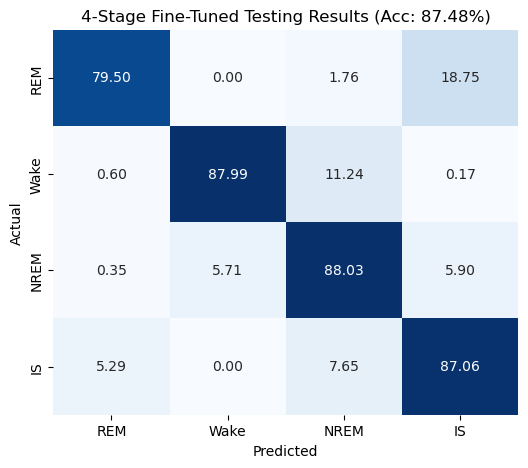


--- Saved fine-tuned models for 4 stages ---


In [ ]:
# --- Prepare Data for Stage 2 ---
print(f"\n--- Preparing Features for Stage 2 Fine-Tuning ---")
train_dataset_fc_ft = extract_stage2_features(bilstm_ft, train_loader)
train_loader_fc_ft = DataLoader(train_dataset_fc_ft, batch_size=batch_size, shuffle=True)

test_dataset_fc_ft = extract_stage2_features(bilstm_ft, test_loader)
test_loader_fc_ft = DataLoader(test_dataset_fc_ft, batch_size=batch_size, shuffle=False) if test_dataset_fc_ft else None

# --- Train Stage 2 flexibly ---
if global_model_output_dim != 3:        # If desired sleep stage number is not equal to the loaded one's
    # Modify dimensions dynamically depending on final outputs from Stage 1 segments
    fc_ft.fc[1] = nn.Linear(segment_length * global_model_output_dim, 64).double().to(device)
    fc_ft.fc[11] = nn.Linear(32, global_model_output_dim).double().to(device)

# --- Calculate Class Weights for Stage 2 ---
labels_s2 = train_dataset_fc_ft.labels.numpy().astype(int) - 1
class_counts_s2 = np.bincount(labels_s2, minlength=global_model_output_dim)
class_counts_s2 = np.maximum(class_counts_s2, 1) # avoid division by zero
class_weights_s2 = len(labels_s2) / (global_model_output_dim * class_counts_s2)
class_weights_tensor_s2 = torch.tensor(class_weights_s2, dtype=torch.double).to(device)

criterion_ft_2 = nn.CrossEntropyLoss(weight=class_weights_tensor_s2)
optimizer_ft_2 = torch.optim.Adam(fc_ft.parameters(), lr=1e-5)
epochs_ft_2 = 20

print(f"--- Fine-Tuning Stage 2 (FCNet) for {global_model_output_dim} Stages ---")
for epoch in range(epochs_ft_2):
    fc_ft.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, (inputs, targets) in enumerate(train_loader_fc_ft):
        inputs = inputs.to(device).double()
        targets = targets.to(device).long() - 1 
        
        optimizer_ft_2.zero_grad()
        outputs = fc_ft(inputs)
        
        loss = criterion_ft_2(outputs, targets)
        loss.backward()
        optimizer_ft_2.step()
        
        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)
        
    acc = 100.0 * correct / max(total, 1)
    
    # Test Evaluation
    if run_test_evaluation:
        fc_ft.eval()
        test_correct, test_total = 0, 0
        with torch.no_grad():
            for test_in, test_tgt in test_loader_fc_ft:
                test_in = test_in.to(device).double()
                test_tgt = test_tgt.to(device).long() - 1
                test_out = fc_ft(test_in)
                test_correct += (torch.argmax(test_out, dim=1) == test_tgt).sum().item()
                test_total += test_tgt.size(0)
                
        test_acc = 100.0 * test_correct / max(test_total, 1)
        
        print(f'Epoch [{epoch+1}/{epochs_ft_2}] | Train Loss: {running_loss/len(train_loader_fc_ft):.4f} | Train Acc: {acc:.2f}% | Test Acc: {test_acc:.2f}%')
    else:
        print(f'Epoch [{epoch+1}/{epochs_ft_2}] | Train Loss: {running_loss/len(train_loader_fc_ft):.4f} | Train Acc: {acc:.2f}% | Test labels are not found/skipped!')

if run_test_evaluation:
    print("\n--- Evaluating Fine-Tuned Model ---")
    fc_ft.eval()
    test_real_labels_ft, test_predicted_labels_ft = [], []

    with torch.no_grad():
        for test_in, test_tgt in test_loader_fc_ft:
            test_in = test_in.to(device).double()
            test_out = fc_ft(test_in)
            val_output_classes = torch.argmax(test_out, dim=1) + 1
            
            test_predicted_labels_ft.extend(val_output_classes.tolist())
            test_real_labels_ft.extend(test_tgt.tolist())

    final_test_acc = 100.0 * np.sum(np.array(test_real_labels_ft) == np.array(test_predicted_labels_ft)) / len(test_real_labels_ft)
    print(f"Final Stage 2 Testing Accuracy on {global_model_output_dim} Stages: {final_test_acc:.2f}%")

    # Map confusion matrix uniquely across the target provided stages
    cf_matrix_ft = confusion_matrix(test_real_labels_ft, test_predicted_labels_ft, labels=global_valid_stages)
    cf_matrix_normalized_ft = cf_matrix_ft / (cf_matrix_ft.sum(axis=1, keepdims=True) + 1e-10) * 100

    plt.figure(figsize=(6, 5), dpi=100)
    sns.heatmap(cf_matrix_normalized_ft, annot=True, fmt='.2f', cmap='Blues', cbar=False, 
                xticklabels=global_class_names, yticklabels=global_class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{global_model_output_dim}-Stage Fine-Tuned Testing Results (Acc: {final_test_acc:.2f}%)')
    plt.show()

# Save the newly tuned extended models
torch.save(bilstm_ft, f'Stage1_tuned_{global_model_output_dim}stages.pkl')
torch.save(fc_ft, f'Stage2_tuned_{global_model_output_dim}stages.pkl')
print(f"\n--- Saved fine-tuned models for {global_model_output_dim} stages ---")

## 5. Run Inference and Save Annotations

Here we load trained models to run pure inference on new recordings. The outputs are formally padded to match original lengths and are saved strictly as `remidx_sleepclass_<name>.txt` within your recording directories. This safely outputs new annotations without ever overwriting the manual `remidx_<name>.txt` files.

In [ ]:
# Define recordings to run inference on
inference_recordings = ['write_in_recording_name_1', 'write_in_recording_name_2'] # Swap for whatever recordings you wish to infer on

# Load models (Switch these paths to standard pretrained if you haven't run Section 4)
inf_stage1_path = os.path.join(model_path, f'Stage1_tuned_{global_model_output_dim}stages.pkl')
inf_stage2_path = os.path.join(model_path, f'Stage2_tuned_{global_model_output_dim}stages.pkl')

print(f"Loading Stage 1 from: {inf_stage1_path}")
inf_bilstm = du.safe_load_model(inf_stage1_path, device)
inf_bilstm.eval()

print(f"Loading Stage 2 from: {inf_stage2_path}")
inf_fc = du.safe_load_model(inf_stage2_path, device)
inf_fc.eval()

for name in inference_recordings:
    print(f"\n--- Processing {name} ---")
    
    # Load the original state file just to find the accurate expected length of the recording
    try:
        m_orig, _ = du.load_stateidx(ppath, name)
        len_m = len(m_orig) - 1
    except Exception as e:
        print(f"Could not load state index bounds for {name}: {e}")
        continue

    # Load and downsample raw features
    eeg = so.loadmat(os.path.join(ppath, name, 'EEG.mat'), squeeze_me=True)['EEG']
    eeg = eeg[:(len_m) * factor]
    eeg = sleepy.downsample_vec(eeg, ndown).astype('float16')

    emg = so.loadmat(os.path.join(ppath, name, 'EMG.mat'), squeeze_me=True)['EMG']
    emg = emg[:(len_m) * factor]
    emg = sleepy.downsample_vec(emg, ndown).astype('float16')

    x_input = np.vstack((eeg, emg)).T
    inputs = StandardScaler().fit_transform(x_input)

    # Generate dummy labels purely to satisfy the CustomDataset requirements (not used in inference)
    # Using 1-indexed dummies assuming global_model_output_dim handles it cleanly
    dummy_m = np.ones(len_m * int(factor/ndown)) 
    
    # --- STAGE 1: biLSTM Inference ---
    inf_dataset = du.CustomDataset(inputs, dummy_m, window_size=window_size, num_classes=global_model_output_dim)
    inf_loader = DataLoader(inf_dataset, batch_size=batch_size, shuffle=False)

    stage1_preds = []
    with torch.no_grad():
        for batch_in, _ in inf_loader:
            batch_in = batch_in.to(device).double()
            outputs = inf_bilstm(batch_in)
            stage1_preds.extend(outputs.tolist())

    # --- Prepare overlapping segments for Stage 2 ---
    idx = int(overlap/2)
    segments = np.array(du.create_segments(stage1_preds, segment_length, overlap))

    axis = (0, 2)
    mean_x = np.nanmean(segments, axis=axis, keepdims=True)
    std_x = np.nanstd(segments, axis=axis, keepdims=True)
    std_x[std_x == 0] = 1
    segments = ((segments - mean_x) / std_x).astype('<f8')

    # --- STAGE 2: FCNet Inference ---
    inf_dataset_fc = du.CustomDatasetFC(segments, np.ones(len(segments)))
    inf_loader_fc = DataLoader(inf_dataset_fc, batch_size=batch_size, shuffle=False)

    final_preds = []
    with torch.no_grad():
        for batch_in_fc, _ in inf_loader_fc:
            batch_in_fc = batch_in_fc.to(device).double()
            val_output = inf_fc(batch_in_fc)
            val_classes = torch.argmax(val_output, dim=1) + 1
            final_preds.extend(val_classes.tolist())

    # --- Format Outputs and Save Safely ---
    # Pad with '0' (unannotated/artifact) at the boundaries based on window overlaps
    scaled_labels = [0] * idx + final_preds + [0] * idx
    # Pair each prediction with '0' to explicitly flag that this was auto-generated
    k_flags = [0] * len(scaled_labels) 

    # Write securely to a new specific classification file
    out_lines = ["%d\t%d\n" % (i, j) for (i, j) in zip(scaled_labels, k_flags)]
    out_filepath = os.path.join(ppath, name, f'remidx_sleepclass_{name}.txt')
    
    # We open in write mode ('w') which will create the file or overwrite a previous prediction file,
    # but inherently will NOT overwrite your original custom remidx_<name>.txt files 
    with open(out_filepath, 'w') as f:
        f.writelines(out_lines)
        
    print(f"Successfully saved {len(scaled_labels)} predicted stages to:")
    print(f" -> {out_filepath}")